# Convirtieron tuberías de PVC en aceite de motor

Una tonelada de PVC de desecho se cotiza en 100 dólares. Una tonelada de lubricante sintético, en 3.212. Este equipo encontró una reacción que va de lo primero a lo segundo a 70 °C — y una sola perilla decide qué tan espeso sale el aceite.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Upcycling of polyvinyl chloride into polyalphaolefin lubricants* · Munyaneza Nuwayo et al., **Nature** (5 de agosto de 2026)

**DOI:** [10.1038/s41586-026-10867-z](https://doi.org/10.1038/s41586-026-10867-z)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-06-pvc-lubricantes-vpao/notebook.ipynb)

**Video:** [Pendiente]

## El plástico que nadie quiere

El mundo produce unos 60 millones de toneladas de PVC al año: tuberías, cables, tarjetas, guantes, juguetes. Es barato, duro y resistente al fuego. También es el plástico más difícil de reciclar, porque el 56,7% de su peso es cloro — y ese cloro se escapa al suelo y al agua junto con los aditivos.

Lo que reportan aquí es una ruta distinta: en vez de intentar volver a hacer PVC, lo desarman para fabricar otra cosa. Mezclan el PVC con una alfa-olefina (una molécula de cadena corta que sirve de ladrillo), le echan cloruro de aluminio (AlCl₃) y lo calientan a 70 °C. El PVC pierde el cloro, se parte en pedazos y esos pedazos se pegan a las olefinas. El resultado es una **polialfaolefina** — el aceite base sintético que llevan los lubricantes de motor modernos. Le pusieron vPAO, por *vinyl-derived*.

El detalle que llama la atención de la química: el PVC funciona como plantilla. Las PAO comerciales necesitan catalizadores de metaloceno para controlar la forma de la cadena; aquí esa forma la impone el esqueleto del propio plástico.

Los aceites que describen tienen viscosidad cinemática a 100 °C (KV100) de 14,9 a 26,3 centistokes, índice de viscosidad hasta 130 y coeficiente de fricción entre 0,08 y 0,15. Esas tres cifras viven en las figuras del paper y **no** están en los datos que abrimos aquí — nuestras tablas traen viscosidad *dinámica* en pascal·segundo, que es otra medida. No las mezclamos.

Lo que sí podemos abrir son siete tablas del material suplementario (*Supplementary Information*, el anexo de datos crudos que Nature publica junto al paper): las S1, S2, S4, S5, S6 y S8, con la dosis de catalizador, los metales que trae el plástico, la estabilidad térmica de diecisiete aceites y el balance de masa y costo. Vamos por partes.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CARGA_REFERENCIA = 50        # mol% de AlCl3 de la condición canónica del paper
PRECIO_PVC = 100             # USD/tonelada (PVC de desecho, Tabla S8)
PRECIO_PAO = 3212            # USD/tonelada (lubricante PAO, Tabla S8)
FUENTE = ('Fuente: Munyaneza Nuwayo et al. (2026), Nature  |  '
          'Datos: material suplementario del paper, Tablas S1-S8')
COLOR_DATOS = '#2563EB'      # azul CaM — dato principal
COLOR_ALERTA = '#DC2626'     # rojo — contraste
COLOR_SECUNDARIO = '#059669' # verde — serie secundaria
COLOR_REFERENCIA = '#D97706' # ámbar — umbral / dato que sobrevive
COLOR_CONTEXTO = '#BBBBBB'   # gris — contexto

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

# Estilo editorial CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga de los 7 CSV transcritos del Supplementary ──────────
dosis = pd.read_csv('datos/alcl3_dosis.csv')            # Tabla S2
olefina = pd.read_csv('datos/olefina_solvente.csv')     # Tabla S1
solventes = pd.read_csv('datos/solventes.csv')          # Tabla S4
metales = pd.read_csv('datos/metales_icpms.csv')        # Tabla S5
termicas = pd.read_csv('datos/propiedades_termicas.csv')# Tabla S6
precios = pd.read_csv('datos/precios_usd_ton.csv')      # Tabla S8
balance = pd.read_csv('datos/balance_masa_costo.csv')   # Tabla S8 + SI 12.2.4

print('Filas por tabla:')
for nombre, df in [('dosis de AlCl3', dosis), ('olefina y solvente', olefina),
                   ('solventes', solventes), ('metales ICP-MS', metales),
                   ('propiedades termicas', termicas), ('precios', precios),
                   ('balance de masa', balance)]:
    print(f'  {nombre:22s} n = {len(df):3d}')

print('\nCada tabla trae entre 5 y 17 condiciones experimentales individuales')
print('(metales: 40 filas = 5 muestras x 8 metales). No son muestreos:')
print('sin replicas por condicion -> sin barras de error.')

# ── Tres numeros que enmarcan todo lo que sigue ────────────────
mult_valor = PRECIO_PAO / PRECIO_PVC
v8 = olefina.loc[olefina.lubricante == 'v8PAO', 'viscosidad_dinamica_pas'].iloc[0]
c8 = olefina.loc[olefina.lubricante == 'c8PAO', 'viscosidad_dinamica_pas'].iloc[0]
print(f'\nMultiplicador de valor PVC -> PAO: {mult_valor:.1f}x '
      f'({PRECIO_PVC} -> {PRECIO_PAO} USD/t)')
print(f'Viscosidad con PVC vs sin PVC (misma olefina C8): '
      f'{v8:.2f} vs {c8:.2f} Pa.s = {v8/c8:.1f}x')
print(f'Rango de viscosidad que abre la dosis de AlCl3: '
      f'{dosis.viscosidad_dinamica_pas.max():.2f} -> '
      f'{dosis.viscosidad_dinamica_pas.min():.2f} Pa.s '
      f'= {dosis.viscosidad_dinamica_pas.max()/dosis.viscosidad_dinamica_pas.min():.1f}x')

Filas por tabla:
  dosis de AlCl3         n =   6
  olefina y solvente     n =   6
  solventes              n =   6
  metales ICP-MS         n =  40
  propiedades termicas   n =  17
  precios                n =   8
  balance de masa        n =   6

Cada tabla trae entre 5 y 17 condiciones experimentales individuales
(metales: 40 filas = 5 muestras x 8 metales). No son muestreos:
sin replicas por condicion -> sin barras de error.

Multiplicador de valor PVC -> PAO: 32.1x (100 -> 3212 USD/t)
Viscosidad con PVC vs sin PVC (misma olefina C8): 3.70 vs 0.10 Pa.s = 37.0x
Rango de viscosidad que abre la dosis de AlCl3: 14.54 -> 0.25 Pa.s = 58.2x


## La perilla

Aquí está.

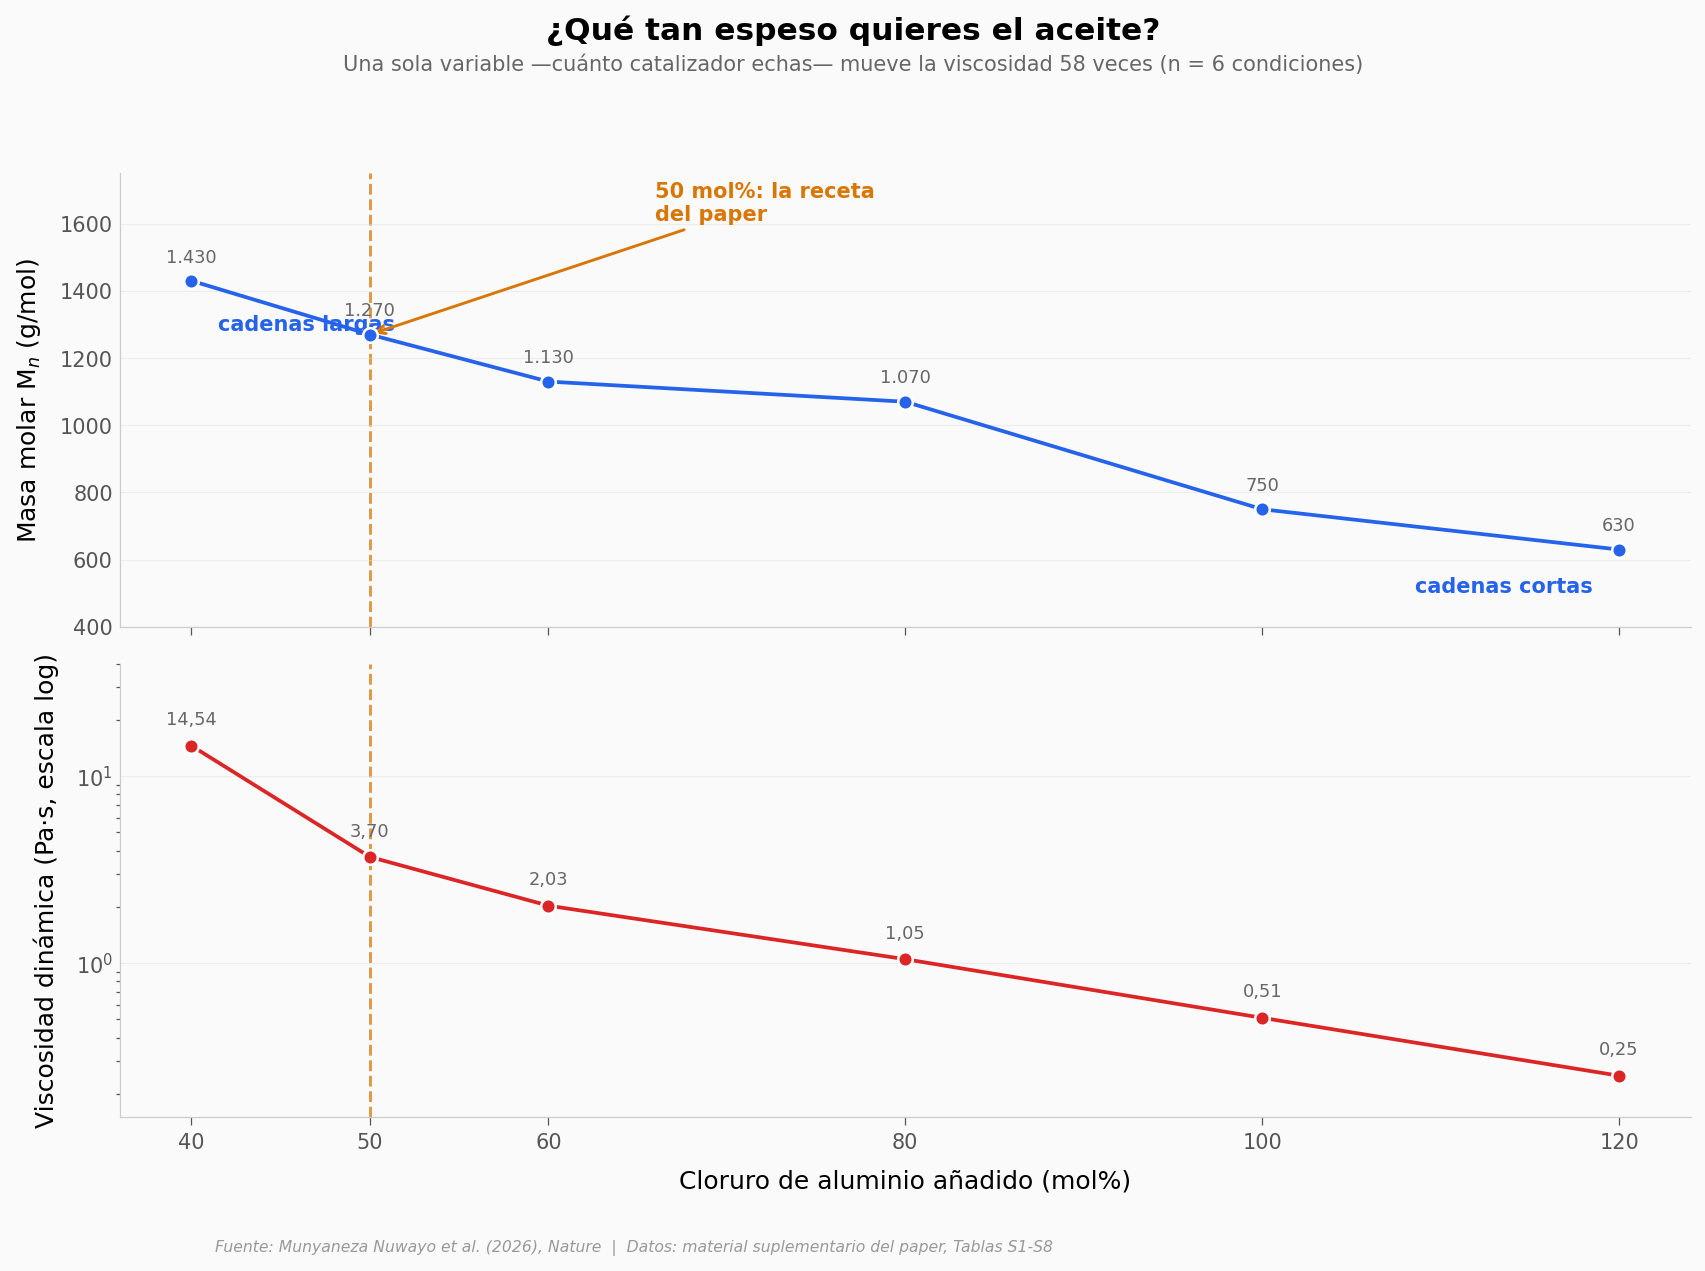

Normalidad (Shapiro-Wilk):
  masa molar   p = 0.748 -> normal
  viscosidad   p = 0.005 -> NO normal

Correlaciones de rangos (Spearman, n = 6):
  AlCl3 vs masa molar    rho = -1.00   p = 0.0028 (exacto, n = 6)
  AlCl3 vs CH2/CH3       rho = -1.00   p = 0.0028 (exacto, n = 6)
  AlCl3 vs viscosidad    rho = -1.00   p = 0.0028 (exacto, n = 6)

Masa molar: 1,430 -> 630 g/mol = factor 2.27
Viscosidad: 14.54 -> 0.25 Pa.s = factor 58.2


In [2]:
d = dosis.sort_values('alcl3_mol_pct')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 7.5), sharex=True)

# ── Panel superior: masa molar ────────────────────────────────
ax1.plot(d.alcl3_mol_pct, d.mn_g_mol, '-o', color=COLOR_DATOS,
         markeredgecolor='white', markeredgewidth=1.2, zorder=5)
ax1.set_ylabel('Masa molar M$_n$ (g/mol)')
ax1.set_ylim(400, 1750)
ax1.text(41.5, 1330, 'cadenas largas', fontsize=10, color=COLOR_DATOS,
         fontweight='bold', ha='left', va='top')
ax1.text(118.5, 520, 'cadenas cortas', fontsize=10, color=COLOR_DATOS,
         fontweight='bold', ha='right', va='center')
for x, y in zip(d.alcl3_mol_pct, d.mn_g_mol):
    ax1.annotate(f'{y:,}'.replace(',', '.'), xy=(x, y), xytext=(0, 9),
                 textcoords='offset points', fontsize=8.5,
                 color='#666666', ha='center')

# ── Panel inferior: viscosidad dinámica (log) ─────────────────
ax2.plot(d.alcl3_mol_pct, d.viscosidad_dinamica_pas, '-o', color=COLOR_ALERTA,
         markeredgecolor='white', markeredgewidth=1.2, zorder=5)
ax2.set_yscale('log')
ax2.set_ylabel('Viscosidad dinámica (Pa·s, escala log)')
ax2.set_xlabel('Cloruro de aluminio añadido (mol%)')
ax2.set_ylim(0.15, 40)
for x, y in zip(d.alcl3_mol_pct, d.viscosidad_dinamica_pas):
    ax2.annotate(f'{y:.2f}'.replace('.', ','), xy=(x, y), xytext=(0, 10),
                 textcoords='offset points', fontsize=8.5,
                 color='#666666', ha='center')

# Condición de referencia del paper
for ax in (ax1, ax2):
    ax.axvline(CARGA_REFERENCIA, color=COLOR_REFERENCIA, linewidth=1.4,
               linestyle='--', alpha=0.75, zorder=1)
ax1.annotate(f'{CARGA_REFERENCIA} mol%: la receta\ndel paper',
             xy=(CARGA_REFERENCIA, 1270), xytext=(66, 1610),
             fontsize=10, fontweight='bold', color=COLOR_REFERENCIA,
             arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.4))

ax2.set_xticks(d.alcl3_mol_pct)
fig.suptitle('¿Qué tan espeso quieres el aceite?', fontsize=15,
             fontweight='bold', y=1.07)
fig.text(0.5, 1.02, 'Una sola variable —cuánto catalizador echas— mueve la '
         'viscosidad 58 veces (n = 6 condiciones)',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/perilla_alcl3.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Estadística: Spearman por defecto (regla 33) ───────────────
print('Normalidad (Shapiro-Wilk):')
for col, etiqueta in [('mn_g_mol', 'masa molar'),
                      ('viscosidad_dinamica_pas', 'viscosidad')]:
    W, p = stats.shapiro(d[col])
    print(f'  {etiqueta:12s} p = {p:.3f} '
          f'{"-> normal" if p > 0.05 else "-> NO normal"}')

print('\nCorrelaciones de rangos (Spearman, n = 6):')
for col, etiqueta in [('mn_g_mol', 'AlCl3 vs masa molar'),
                      ('ich2_ich3', 'AlCl3 vs CH2/CH3'),
                      ('viscosidad_dinamica_pas', 'AlCl3 vs viscosidad')]:
    rho, p = stats.spearmanr(d.alcl3_mol_pct, d[col])
    # scipy devuelve p = 0.0 cuando |rho| = 1 (la aproximacion t diverge).
    # El p exacto por permutacion con n = 6 es 2/720 = 0.0028, y es el minimo posible.
    if abs(rho) == 1.0:
        p = 2 / 720
    print(f'  {etiqueta:22s} rho = {rho:+.2f}   p = {p:.4f} (exacto, n = 6)')

print(f'\nMasa molar: {d.mn_g_mol.max():,} -> {d.mn_g_mol.min():,} g/mol '
      f'= factor {d.mn_g_mol.max()/d.mn_g_mol.min():.2f}')
print(f'Viscosidad: {d.viscosidad_dinamica_pas.max():.2f} -> '
      f'{d.viscosidad_dinamica_pas.min():.2f} Pa.s '
      f'= factor {d.viscosidad_dinamica_pas.max()/d.viscosidad_dinamica_pas.min():.1f}')

## Lo que hay que mirar

El catalizador no es solo un acelerador: es la tijera. Cuanta más AlCl₃ entra, más se parte la cadena y más corta queda la molécula. De 40 a 120 mol%, la masa molar cae de 1.430 a 630 g/mol — un factor de 2,27.

Lo que llama la atención es el panel de abajo. Esa caída de 2,27 en tamaño se traduce en una caída de **58,2 veces** en viscosidad: de 14,54 a 0,25 Pa·s. Un cambio moderado en la molécula se amplifica en la propiedad que al usuario le importa. Por eso el eje va en escala logarítmica: en escala lineal, los cuatro puntos de la derecha se aplastarían contra el cero.

Las tres correlaciones dan ρ = −1,00 (p = 0,003 exacto — con n = 6 no existe un p más pequeño: solo 2 de las 720 ordenaciones posibles dan un orden perfecto): orden perfecto en las seis condiciones. Vale la pena leer ese número con cuidado. Son **seis puntos, una corrida por condición y sin réplicas** — no hay barras de error posibles, y un ρ de −1 con n = 6 dice que el orden se respetó, no que exista una ley universal detrás. Usamos Spearman y no Pearson porque la viscosidad no pasa la prueba de normalidad (Shapiro p = 0,005); sobre rangos, la relación es monótona sin necesidad de suponer una recta.

A 50 mol% —la receta que el paper usa como referencia— la molécula pesa 1.270 g/mol y el aceite queda en 3,70 Pa·s. Es el punto donde, según el material suplementario, la decloración ya está completa.

Y hay un borde: por debajo de 40 mol% el producto deja de fluir. Sale una pasta tipo grasa que ni siquiera se puede medir en el reómetro. La perilla tiene tope.

## La basura no llega sola

Un aceite hecho de plástico de desecho suena a mala idea por una razón concreta: el PVC no es solo PVC. Para que una tubería sea rígida y un guante flexible hay que cargarle aditivos — carbonato de calcio, estabilizantes de estaño, pigmentos de titanio, compuestos de zinc. Todo eso viaja con el residuo.

El equipo midió ocho metales por espectrometría de masas (ICP-MS) en cinco muestras: el PVC de desecho tal cual llega, el mismo PVC después de lavarlo, PVC virgen de referencia y dos de los lubricantes finales.

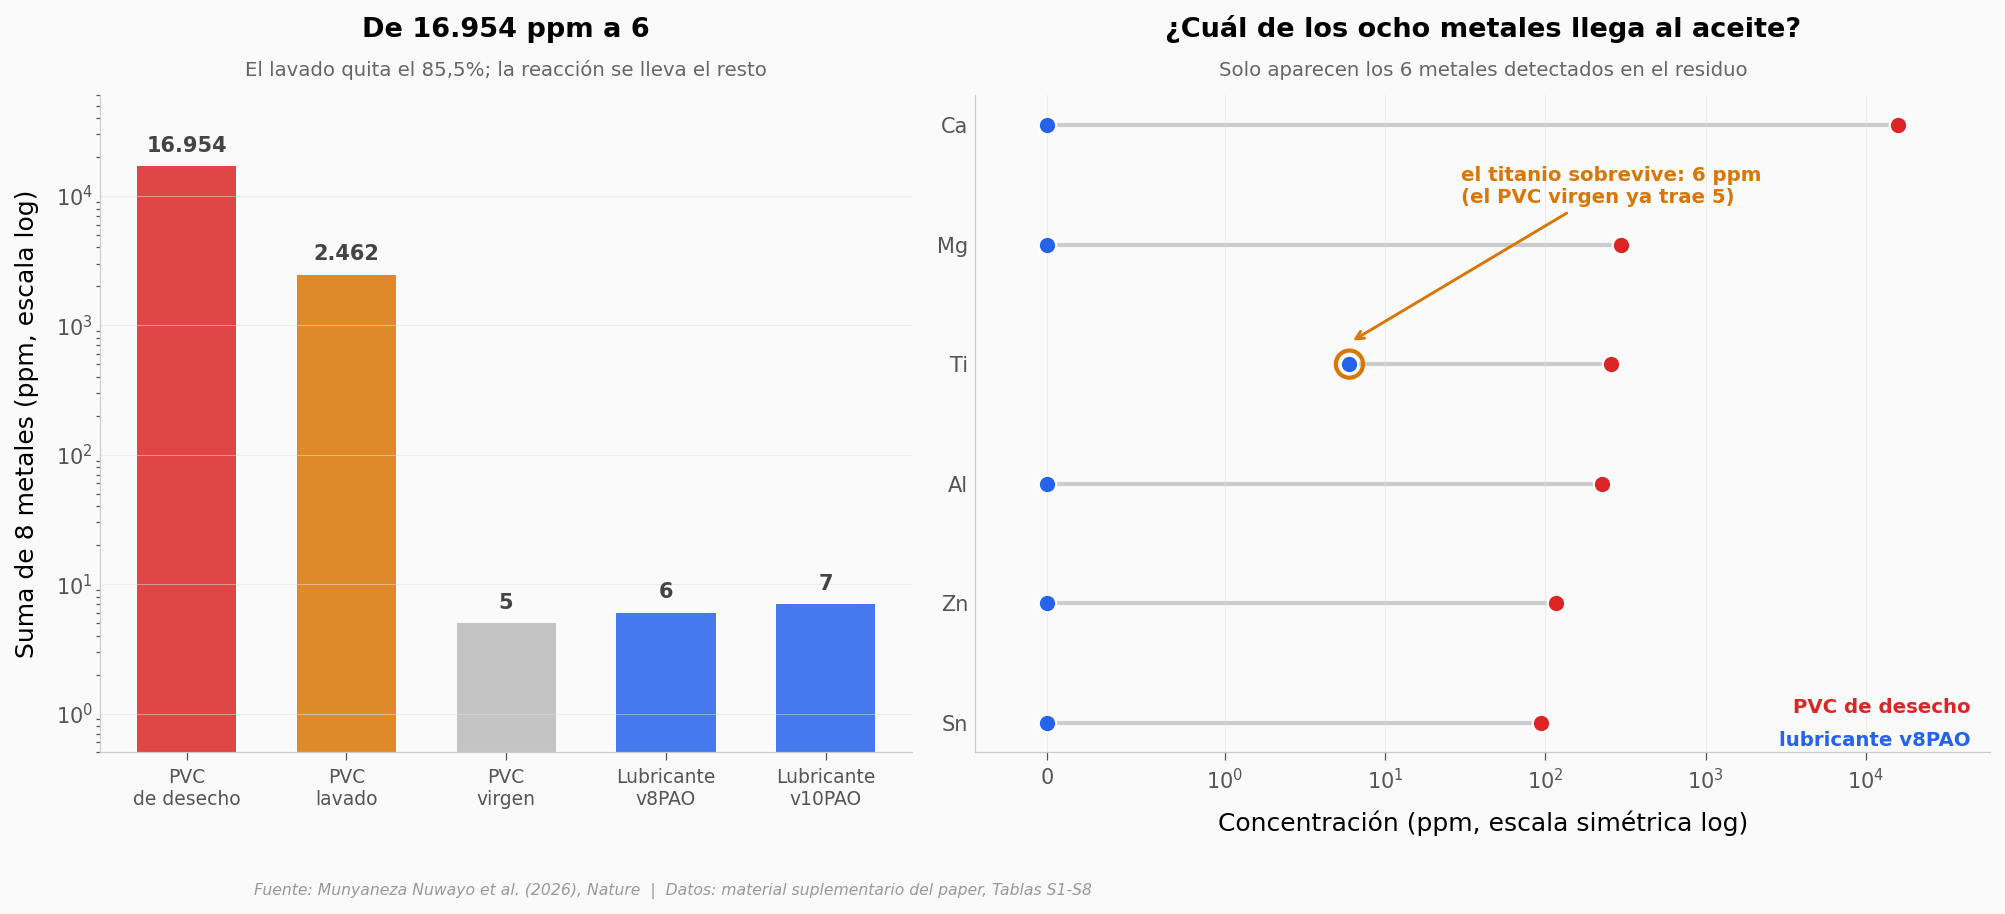

Metales totales: 16,954 ppm (residuo) -> 6 ppm (v8PAO) = 99.965% menos
Solo el lavado previo elimina el 85.5%
Calcio: 15,958 ppm en el residuo -> 0 en el lubricante (94% de toda la carga metalica)

Metales detectados en cada lubricante (ppm):
           muestra metal  concentracion_ppm
             v8PAO    Ti                  6
v10PAO-mix-hexanos    Ti                  7


In [3]:
orden = ['PVC residuo', 'PVC lavado', 'PVC virgen', 'v8PAO', 'v10PAO-mix-hexanos']
etiquetas = ['PVC\nde desecho', 'PVC\nlavado', 'PVC\nvirgen',
             'Lubricante\nv8PAO', 'Lubricante\nv10PAO']
totales = metales.groupby('muestra').concentracion_ppm.sum().reindex(orden)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8),
                               gridspec_kw={'width_ratios': [1, 1.25]})

# ── Panel izquierdo: carga total de metales ───────────────────
colores = [COLOR_ALERTA, COLOR_REFERENCIA, COLOR_CONTEXTO,
           COLOR_DATOS, COLOR_DATOS]
barras = ax1.bar(range(len(orden)), totales.values.clip(min=0.5), color=colores,
                 alpha=0.85, width=0.62)
ax1.set_yscale('log')
ax1.set_ylim(0.5, 60000)
ax1.set_xticks(range(len(orden)))
ax1.set_xticklabels(etiquetas, fontsize=9)
ax1.set_ylabel('Suma de 8 metales (ppm, escala log)')
for i, v in enumerate(totales.values):
    ax1.annotate(f'{v:,}'.replace(',', '.'), xy=(i, max(v, 0.5)), xytext=(0, 7),
                 textcoords='offset points', ha='center', fontsize=10,
                 fontweight='bold', color='#444444')
ax1.set_title('De 16.954 ppm a 6', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'El lavado quita el 85,5%; la reacción se lleva el resto',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')

# ── Panel derecho: metal por metal (dumbbell) ─────────────────
res = metales[metales.muestra == 'PVC residuo'].set_index('metal').concentracion_ppm
lub = metales[metales.muestra == 'v8PAO'].set_index('metal').concentracion_ppm
presentes = res[res > 0].sort_values()
ypos = np.arange(len(presentes))
for i, metal in enumerate(presentes.index):
    ax2.plot([presentes[metal], lub[metal]], [i, i], color='#CCCCCC',
             linewidth=2, zorder=1, solid_capstyle='round')
ax2.scatter(presentes.values, ypos, s=70, color=COLOR_ALERTA,
            edgecolors='white', linewidths=1, zorder=5)
ax2.scatter(lub[presentes.index].values, ypos, s=70, color=COLOR_DATOS,
            edgecolors='white', linewidths=1, zorder=5)
# El titanio es el único que sobrevive: resaltarlo
i_ti = list(presentes.index).index('Ti')
ax2.scatter([lub['Ti']], [i_ti], s=170, facecolors='none',
            edgecolors=COLOR_REFERENCIA, linewidths=2, zorder=6)
ax2.annotate('el titanio sobrevive: 6 ppm\n(el PVC virgen ya trae 5)',
             xy=(lub['Ti'], i_ti + 0.18), xytext=(30, i_ti + 1.35),
             fontsize=9.5, fontweight='bold', color=COLOR_REFERENCIA,
             arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.4))
ax2.set_xscale('symlog', linthresh=1)
ax2.set_xlim(-0.4, 60000)
ax2.set_yticks(ypos)
ax2.set_yticklabels(presentes.index, fontsize=10)
ax2.set_xlabel('Concentración (ppm, escala simétrica log)')
ax2.grid(axis='y', visible=False)
ax2.grid(axis='x', visible=True)
ax2.text(0.98, 0.06, 'PVC de desecho', transform=ax2.transAxes, fontsize=9.5,
         color=COLOR_ALERTA, fontweight='bold', ha='right')
ax2.text(0.98, 0.01, 'lubricante v8PAO', transform=ax2.transAxes, fontsize=9.5,
         color=COLOR_DATOS, fontweight='bold', ha='right')
ax2.set_title('¿Cuál de los ocho metales llega al aceite?',
              fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Solo aparecen los 6 metales detectados en el residuo',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/metales_icpms.png', dpi=200, bbox_inches='tight')
plt.show()

reduccion = 100 * (1 - totales['v8PAO'] / totales['PVC residuo'])
lavado = 100 * (1 - totales['PVC lavado'] / totales['PVC residuo'])
print(f'Metales totales: {totales["PVC residuo"]:,} ppm (residuo) -> '
      f'{totales["v8PAO"]} ppm (v8PAO) = {reduccion:.3f}% menos')
print(f'Solo el lavado previo elimina el {lavado:.1f}%')
print(f'Calcio: {res["Ca"]:,} ppm en el residuo -> {lub["Ca"]} en el lubricante '
      f'({100*res["Ca"]/totales["PVC residuo"]:.0f}% de toda la carga metalica)')
print('\nMetales detectados en cada lubricante (ppm):')
print(metales[metales.muestra.isin(['v8PAO', 'v10PAO-mix-hexanos'])]
      .query('concentracion_ppm > 0').to_string(index=False))

## De la tubería al frasco

El calcio, que era el 94% de la carga metálica del residuo, desaparece por completo. Lo único que cruza al aceite es titanio: 6 ppm en el v8PAO y 7 en el v10PAO. Y ahí hay un matiz honesto — el PVC **virgen**, el que nunca fue basura, ya traía 5 ppm de titanio. Casi todo el titanio del producto final no viene del reciclaje.

Hasta aquí, sin embargo, casi todo salió de PVC de laboratorio: polvo limpio, comprado, homogéneo. La pregunta que decide si esto sirve para algo es otra. El equipo repitió la reacción con basura de verdad — tarjetas plásticas, guantes, tuberías, ranas de juguete y una mezcla de todo — y midió la estabilidad térmica de los diecisiete aceites resultantes.

Dos temperaturas importan: **Td5%**, a la que el aceite ha perdido el 5% de su masa (dónde empieza a degradarse), y **Tg**, la temperatura de transición vítrea, por debajo de la cual deja de fluir.

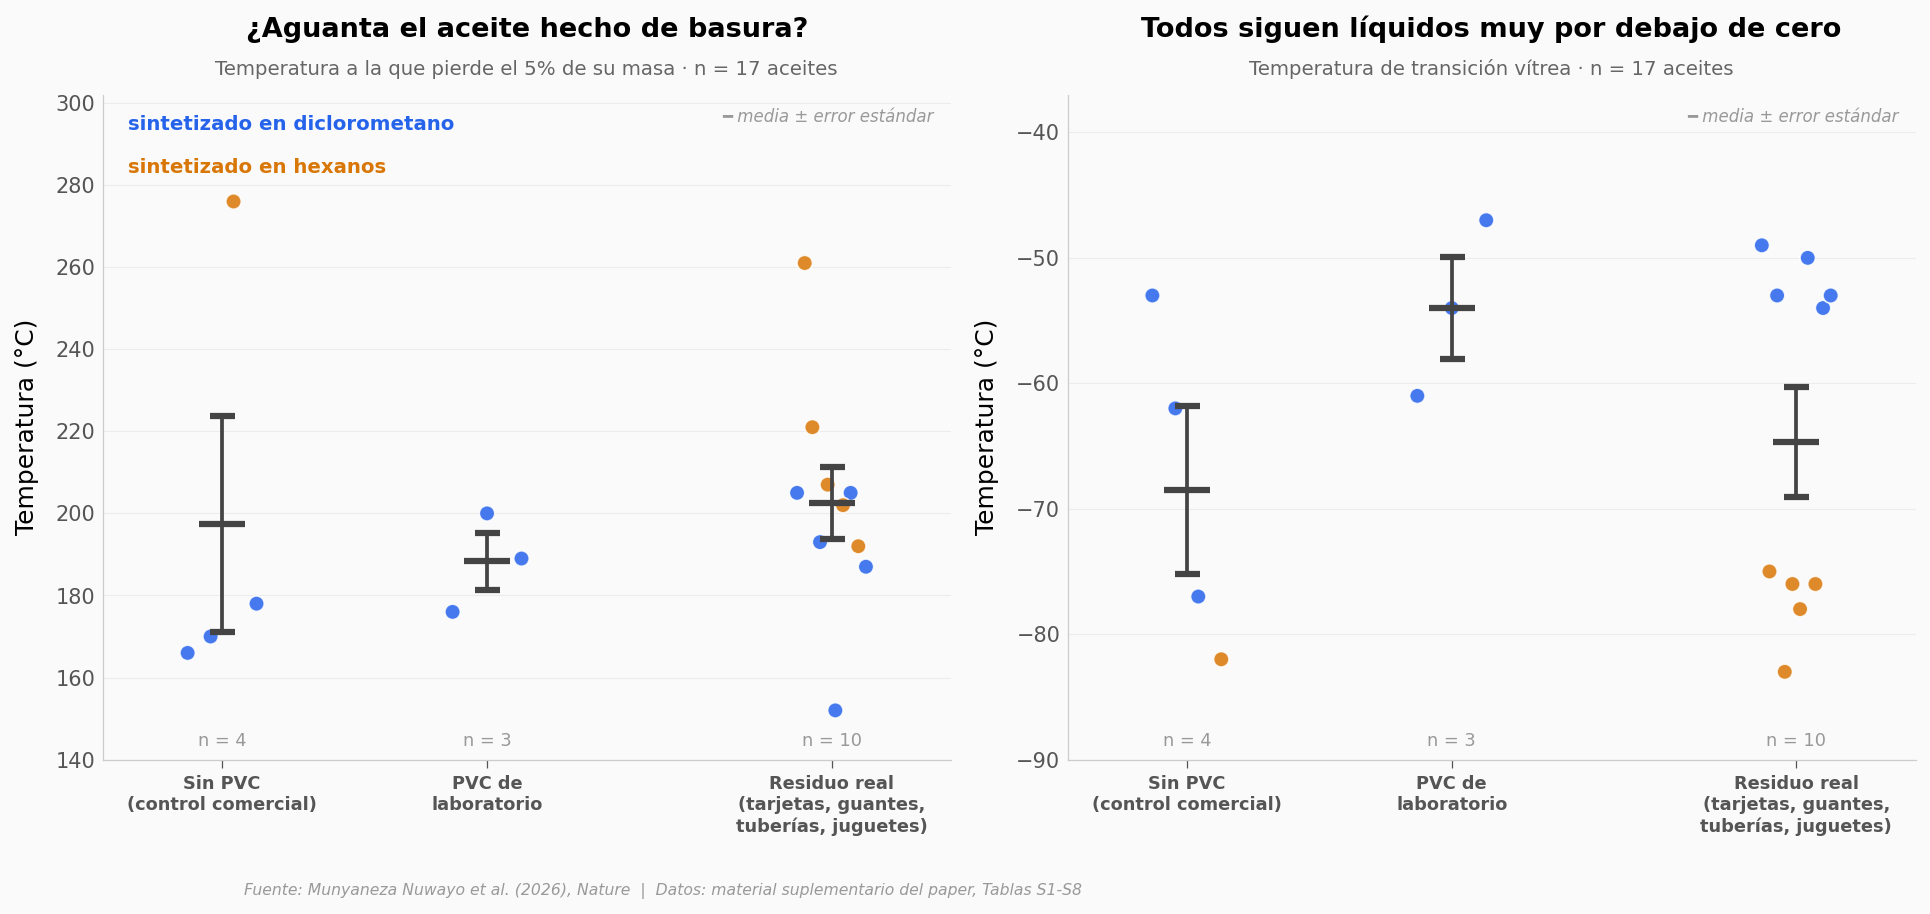

Td5% residuo real (n = 10) vs PVC de laboratorio (n = 3)
  medianas: 204 vs 189 °C
  Mann-Whitney U = 23.0, p = 0.204, r rango-biserial = +0.53 -> NO hay diferencia demostrada
  (el efecto puntual es mediano y favorece al residuo real: +14 °C de media — el n = 3 no da potencia para resolverlo)
  residuo real: rango 152-261 °C, mediana 204, IQR 192-206

OJO — el signo se invierte segun el solvente (Td5%, diferencias absolutas):
  DCM      con PVC (n=8) media 188 °C  vs  sin PVC (n=3) media 171 °C  -> +17 °C
  hexanos  con PVC (n=5) media 217 °C  vs  sin PVC (n=1) media 276 °C  -> -59 °C

Transicion vitrea: todos entre -83 y -47 °C.


In [4]:
def grupo(f):
    if f == 'sin PVC':
        return 'Sin PVC\n(control comercial)'
    if f == 'lab-grade':
        return 'PVC de\nlaboratorio'
    return 'Residuo real\n(tarjetas, guantes,\ntuberías, juguetes)'

t = termicas.copy()
t['grupo'] = t.feedstock.map(grupo)
grupos = ['Sin PVC\n(control comercial)', 'PVC de\nlaboratorio',
          'Residuo real\n(tarjetas, guantes,\ntuberías, juguetes)']
posiciones = [0, 1, 2.3]
color_solv = {'DCM': COLOR_DATOS, 'hexanos': COLOR_REFERENCIA}

np.random.seed(42)  # jitter reproducible
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

for ax, col, titulo, sub, lim in [
        (axes[0], 'td5_c', '¿Aguanta el aceite hecho de basura?',
         'Temperatura a la que pierde el 5% de su masa · n = 17 aceites',
         (140, 302)),
        (axes[1], 'tg_c', 'Todos siguen líquidos muy por debajo de cero',
         'Temperatura de transición vítrea · n = 17 aceites', (-90, -37))]:
    ax.set_ylim(*lim)
    for i, g in enumerate(grupos):
        sub_df = t[t.grupo == g]
        n = len(sub_df)
        x = np.linspace(posiciones[i] - 0.13, posiciones[i] + 0.13, n)
        np.random.shuffle(x)
        ax.scatter(x, sub_df[col], s=55, alpha=0.85, zorder=5,
                   c=[color_solv[s] for s in sub_df.solvente],
                   edgecolors='white', linewidths=0.8)
        media = sub_df[col].mean()
        sem = sub_df[col].std(ddof=1) / np.sqrt(n)
        ax.errorbar(posiciones[i], media, yerr=sem, fmt='_', color='#444444',
                    markersize=22, markeredgewidth=3, capsize=6,
                    capthick=1.5, zorder=6)
        ax.annotate(f'n = {n}', xy=(posiciones[i], 0.02),
                    xycoords=('data', 'axes fraction'), ha='center',
                    fontsize=8.5, color='#999999')
    ax.set_xticks(posiciones)
    ax.set_xticklabels(grupos, fontsize=8.5, fontweight='bold')
    ax.set_xlim(-0.45, 2.75)
    ax.set_ylabel('Temperatura (°C)')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, sub, transform=ax.transAxes, fontsize=9.5,
            color='#666666', ha='center')
    ax.text(0.98, 0.98, '━ media ± error estándar', transform=ax.transAxes, fontsize=8,
            color='#999999', ha='right', va='top', style='italic')

axes[0].text(0.03, 0.97, 'sintetizado en diclorometano', transform=axes[0].transAxes,
             fontsize=9.5, color=COLOR_DATOS, fontweight='bold', va='top')
axes[0].text(0.03, 0.905, 'sintetizado en hexanos', transform=axes[0].transAxes,
             fontsize=9.5, color=COLOR_REFERENCIA, fontweight='bold', va='top')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/estabilidad_termica.png', dpi=200, bbox_inches='tight')
plt.show()

# ── ¿El residuo real rinde peor que el PVC de laboratorio? ─────
real = t[t.feedstock.isin(['tarjetas', 'guantes', 'tuberias',
                           'ranas de juguete', 'mezcla residuos'])].td5_c
lab = t[t.feedstock == 'lab-grade'].td5_c
U, p = stats.mannwhitneyu(real, lab, alternative='two-sided')
print(f'Td5% residuo real (n = {len(real)}) vs PVC de laboratorio (n = {len(lab)})')
print(f'  medianas: {real.median():.0f} vs {lab.median():.0f} °C')
r_rb = 2 * U / (len(real) * len(lab)) - 1   # rango-biserial: efecto para Mann-Whitney
print(f'  Mann-Whitney U = {U:.1f}, p = {p:.3f}, r rango-biserial = {r_rb:+.2f} '
      f'-> {"diferencia detectada" if p < 0.05 else "NO hay diferencia demostrada"}')
print(f'  (el efecto puntual es mediano y favorece al residuo real: '
      f'{real.mean()-lab.mean():+.0f} °C de media — el n = 3 no da potencia para resolverlo)')
print(f'  residuo real: rango {real.min():.0f}-{real.max():.0f} °C, '
      f'mediana {real.median():.0f}, IQR {real.quantile(.25):.0f}-{real.quantile(.75):.0f}')

print('\nOJO — el signo se invierte segun el solvente (Td5%, diferencias absolutas):')
for solv in ['DCM', 'hexanos']:
    sub_s = t[t.solvente == solv]
    con = sub_s[sub_s.feedstock != 'sin PVC'].td5_c
    sin = sub_s[sub_s.feedstock == 'sin PVC'].td5_c
    print(f'  {solv:8s} con PVC (n={len(con)}) media {con.mean():.0f} °C  vs  '
          f'sin PVC (n={len(sin)}) media {sin.mean():.0f} °C  '
          f'-> {con.mean()-sin.mean():+.0f} °C')
print('\nTransicion vitrea: todos entre '
      f'{t.tg_c.min():.0f} y {t.tg_c.max():.0f} °C.')

## ¿Y cuánto de esto es realmente basura?

Los diez aceites hechos de residuo real quedan en un rango de 152 a 261 °C, con mediana 204 °C. Los tres de PVC de laboratorio, mediana 189 °C. La prueba de Mann-Whitney da p = 0,204: con estos números **no hay diferencia demostrada** entre usar plástico limpio y usar basura. Ni mejor ni peor — sin evidencia de que importe.

Un cuidado que los datos imponen: no se puede decir "el aceite con PVC es más estable" a secas. En diclorometano, los aceites con PVC empiezan a degradarse 17 °C más tarde que el control comercial — diferencia de medias que, con n = 8 contra 3, tampoco pasa la prueba (Mann-Whitney p = 0,12). En hexanos, 59 °C **antes** — y ahí el control es un único dato, así que esa diferencia ni siquiera admite prueba. El solvente manda tanto como el plástico.

Queda la pregunta que decide si esto es reciclaje o marketing. La reacción no es solo PVC: necesita 1-deceno, que es una olefina petroquímica virgen. ¿Cuánto del frasco final viene de la basura?

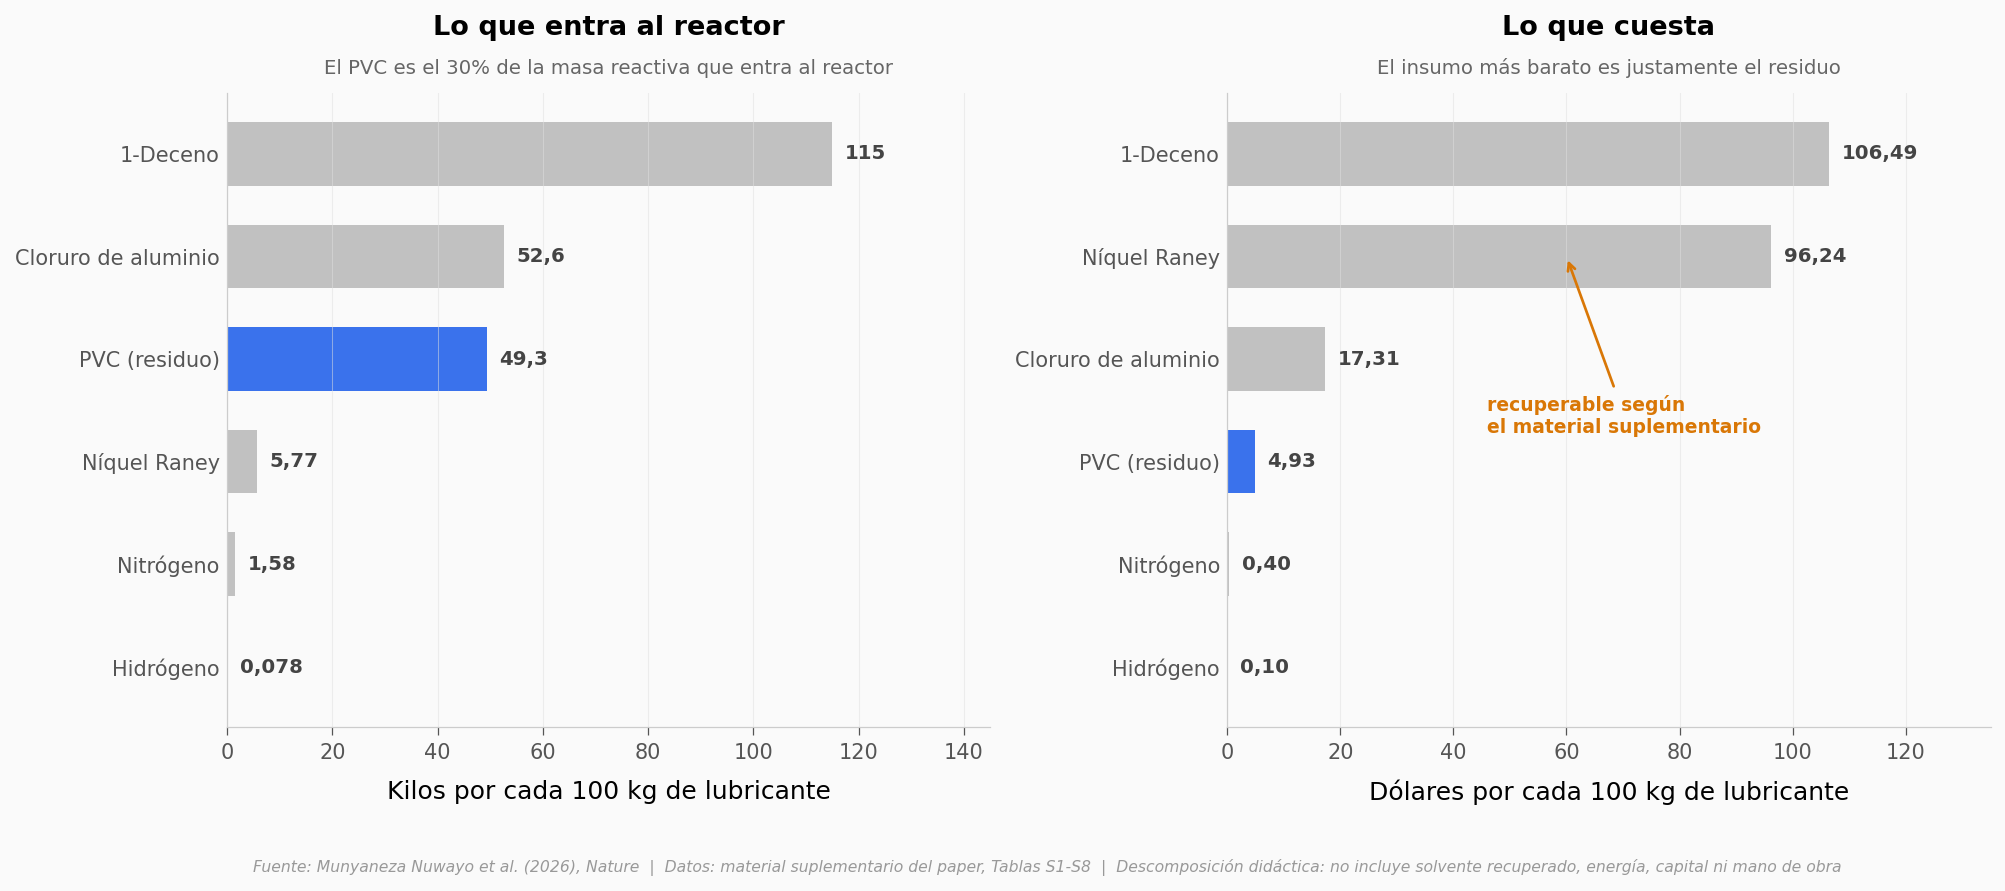

Insumos del paso de acoplamiento (por 100 kg de lubricante):
  1-Deceno                106.49 USD  ( 82.7% del subtotal)
  Cloruro de aluminio      17.31 USD  ( 13.4% del subtotal)
  PVC (residuo)             4.93 USD  (  3.8% del subtotal)
  subtotal                128.73 USD

El PVC aporta el 30% de la masa reactiva (PVC + 1-deceno) y el 3.8% de este costo.
Valor de mercado: PVC de desecho 100 USD/t -> lubricante PAO 3.212 USD/t = 32.1x


In [5]:
# Nombres con la ortografía correcta para mostrar al lector
NOMBRE = {'Niquel Raney': 'Níquel Raney', 'Nitrogeno': 'Nitrógeno',
          'Hidrogeno': 'Hidrógeno', 'Cloruro de aluminio': 'Cloruro de aluminio',
          '1-Deceno': '1-Deceno', 'PVC (residuo)': 'PVC (residuo)'}
balance['nombre'] = balance.material.map(NOMBRE)

b = balance.sort_values('kg_por_100kg_lubricante')
col_barra = [COLOR_DATOS if m.startswith('PVC') else COLOR_CONTEXTO
             for m in b.material]
col_barra_costo = [COLOR_DATOS if m.startswith('PVC') else COLOR_CONTEXTO
                   for m in balance.sort_values('costo_usd_por_100kg').material]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.6))

# ── Panel izquierdo: masa ─────────────────────────────────────
ax1.barh(b.nombre, b.kg_por_100kg_lubricante, color=col_barra,
         alpha=0.9, height=0.62)
ax1.set_xlabel('Kilos por cada 100 kg de lubricante')
ax1.set_xlim(0, 145)
for m, v in zip(b.nombre, b.kg_por_100kg_lubricante):
    ax1.annotate(f'{v:g}'.replace('.', ','), xy=(v, m), xytext=(6, 0),
                 textcoords='offset points', va='center', fontsize=9.5,
                 color='#444444', fontweight='bold')
ax1.set_title('Lo que entra al reactor', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'El PVC es el 30% de la masa reactiva que entra al reactor',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.grid(axis='y', visible=False)
ax1.grid(axis='x', visible=True)

# ── Panel derecho: costo ──────────────────────────────────────
bc = balance.sort_values('costo_usd_por_100kg')
ax2.barh(bc.nombre, bc.costo_usd_por_100kg, color=col_barra_costo,
         alpha=0.9, height=0.62)
ax2.set_xlabel('Dólares por cada 100 kg de lubricante')
ax2.set_xlim(0, 135)
for m, v in zip(bc.nombre, bc.costo_usd_por_100kg):
    ax2.annotate(f'{v:.2f}'.replace('.', ','), xy=(v, m), xytext=(6, 0),
                 textcoords='offset points', va='center', fontsize=9.5,
                 color='#444444', fontweight='bold')
ax2.annotate('recuperable según\nel material suplementario',
             xy=(60, 'Níquel Raney'), xytext=(46, 2.45), fontsize=9,
             color=COLOR_REFERENCIA, fontweight='bold', va='center',
             arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.3))
ax2.set_title('Lo que cuesta', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'El insumo más barato es justamente el residuo',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.grid(axis='y', visible=False)
ax2.grid(axis='x', visible=True)

fig.text(0.13, -0.05, FUENTE + '  |  Descomposición didáctica: no incluye '
         'solvente recuperado, energía, capital ni mano de obra',
         fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/masa_y_costo.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Métrica derivada, definida explícitamente ──────────────────
# "Masa reactiva" = PVC + 1-deceno (los dos que se incorporan al producto).
# El AlCl3 es catalizador estequiometrico: participa pero no queda en el aceite.
reactivos = balance[balance.material.isin(['1-Deceno', 'PVC (residuo)'])]
pvc_masa = reactivos.set_index('material').kg_por_100kg_lubricante['PVC (residuo)']
pct_masa = 100 * pvc_masa / reactivos.kg_por_100kg_lubricante.sum()

# "Tres insumos principales" = 1-deceno + AlCl3 + PVC (los del paso de acoplamiento).
tres = balance[balance.material.isin(['1-Deceno', 'PVC (residuo)',
                                      'Cloruro de aluminio'])]
total3 = tres.costo_usd_por_100kg.sum()
print('Insumos del paso de acoplamiento (por 100 kg de lubricante):')
for _, r in tres.sort_values('costo_usd_por_100kg', ascending=False).iterrows():
    print(f'  {r.nombre:22s} {r.costo_usd_por_100kg:7.2f} USD  '
          f'({100*r.costo_usd_por_100kg/total3:5.1f}% del subtotal)')
print(f'  {"subtotal":22s} {total3:7.2f} USD')
print(f'\nEl PVC aporta el {pct_masa:.0f}% de la masa reactiva '
      f'(PVC + 1-deceno) y el {100*4.93/total3:.1f}% de este costo.')
print(f'Valor de mercado: PVC de desecho {PRECIO_PVC} USD/t -> '
      f'lubricante PAO {PRECIO_PAO:,} USD/t'.replace(',', '.') +
      f' = {PRECIO_PAO/PRECIO_PVC:.1f}x')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La dosis de AlCl₃ controla la viscosidad del aceite | ✅ | ρ = −1,00 (Spearman) en las tres variables medidas. 14,54 → 0,25 Pa·s entre 40 y 120 mol%. **n = 6, una corrida por condición, sin réplicas** → no hay barras de error y el orden perfecto no prueba una ley general |
| El PVC sube la viscosidad frente a la misma olefina sin PVC | ✅ | v8PAO 3,70 vs c8PAO 0,10 Pa·s = 37,0×, **con una sola medición por condición (n = 1 vs 1)**: es la magnitud reportada, no una diferencia con prueba estadística |
| La reacción limpia los metales del plástico de desecho | ✅ | 16.954 → 6 ppm (99,965%). El lavado previo ya quita el 85,5%; el calcio (15.958 ppm) desaparece del todo |
| El titanio del lubricante viene del residuo | ⚠️ | Sobreviven 6-7 ppm de Ti, pero el PVC **virgen** ya traía 5 ppm. La mayor parte no es atribuible al reciclaje |
| Usar basura real no empeora la estabilidad térmica | ✅ | Mann-Whitney sobre Td5%: residuo real (n = 10, mediana 204 °C) vs laboratorio (n = 3, mediana 189 °C), p = 0,204, r rango-biserial = 0,53 (el efecto puntual, +14 °C de media, va a favor del residuo real). Ausencia de diferencia demostrada — con n = 3 en un grupo, tampoco descarta una diferencia pequeña |
| "El aceite con PVC es más estable que el comercial" | ❌ | El signo se invierte por solvente: +17 °C en diclorometano, −59 °C en hexanos (y ahí el control es un solo dato). No se puede afirmar sin nombrar el solvente |
| Los aceites siguen fluidos muy por debajo de cero | ✅ | Tg entre −47 y −83 °C en los 17 aceites |
| El PVC domina la receta | ❌ | Aporta el 30% de la masa reactiva y el 3,8% del costo de los tres insumos del acoplamiento. El 1-deceno —petroquímico virgen— pone el 83% |
| Es económicamente atractivo a escala industrial | ⚠️ | El paper lo plantea como potencial: su análisis tecno-económico modela una planta de 50.000 t/año. Es un modelo con supuestos de mercado, no una planta construida |
| KV100 14,9-26,3 cSt · índice de viscosidad hasta 130 · fricción 0,08-0,15 | ⚠️ | Cifras del abstract. Viven en figuras del paper, no en las tablas que abrimos. Nuestros datos son viscosidad **dinámica** (Pa·s), otra magnitud — no comparables |

> **Limitaciones**
>
> - **n pequeño en todo:** entre 5 y 17 condiciones por tabla (la de metales trae 40 filas, pero son 5 muestras × 8 metales). Son condiciones experimentales individuales, no muestreos. Sin réplicas por condición no hay barras de error posibles.
> - **Solvente confundido con olefina:** los aceites hechos en hexanos se degradan a 50% de masa 76 °C más tarde que los de diclorometano, pero casi todos los de hexanos son también v10PAO. No se puede separar el efecto del solvente del de la olefina con estos datos.
> - **Los solventes clorados no ramifican más, sin más:** el tetracloruro de carbono (CH₂/CH₃ = 2,48) cae dentro del rango de los hidrocarburos. La generalización no se sostiene.
> - **Temperaturas en escala de intervalo:** Td5%, Td50% y Tg se comparan en diferencias absolutas (°C), nunca en porcentajes.
> - **ρ de Spearman opera sobre rangos:** ρ² no se interpreta como varianza explicada.
> - **La descomposición de costo es didáctica, no el análisis tecno-económico del paper.** Excluye los hexanos (que se recuperan por destilación), el capital, la energía y la mano de obra; el níquel Raney aparece a precio de lista aunque el material suplementario lo describe como reciclable. Un costo de producción real usa el modelo completo de las Tablas S7-S9.
> - **Datos no reproducidos aquí:** el cloro residual (<100 ppm, >99,98% de reducción), la fricción a seis meses y el volumen de desgaste (243.000 µm³ para el vPAO-DCM frente a 24.900 del PAO comercial) salen del texto del material suplementario, no de tablas que podamos recalcular.
> - **El repositorio Dryad del paper todavía no es público** al momento de escribir esto, así que trabajamos sobre las tablas del material suplementario.

## Ahora tú

**¿Qué solvente produce las cadenas más ramificadas?** La tabla `solventes.csv` mide CH₂/CH₃ en seis solventes con la misma carga de catalizador. Menos CH₂ por cada CH₃ significa más ramas. Prueba ordenándolos: `solventes.sort_values('ich2_ich3')`.

**Si la ramificación y la viscosidad van de la mano, ¿cuánto de la una predice la otra?** En `olefina_solvente.csv` tienes ambas columnas para seis aceites. Corre `stats.spearmanr(olefina.branching_ratio_pct, olefina.viscosidad_dinamica_pas)` — y acuérdate de mirar el n antes de creerle al ρ.

**¿A qué precio del 1-deceno dejaría de tener sentido el proceso?** Cambia `PRECIO_PAO` en la celda de configuración y recalcula el margen contra el subtotal de insumos. ¿Cuánto tendría que caer el lubricante para que los 106,49 dólares de olefina no se paguen?

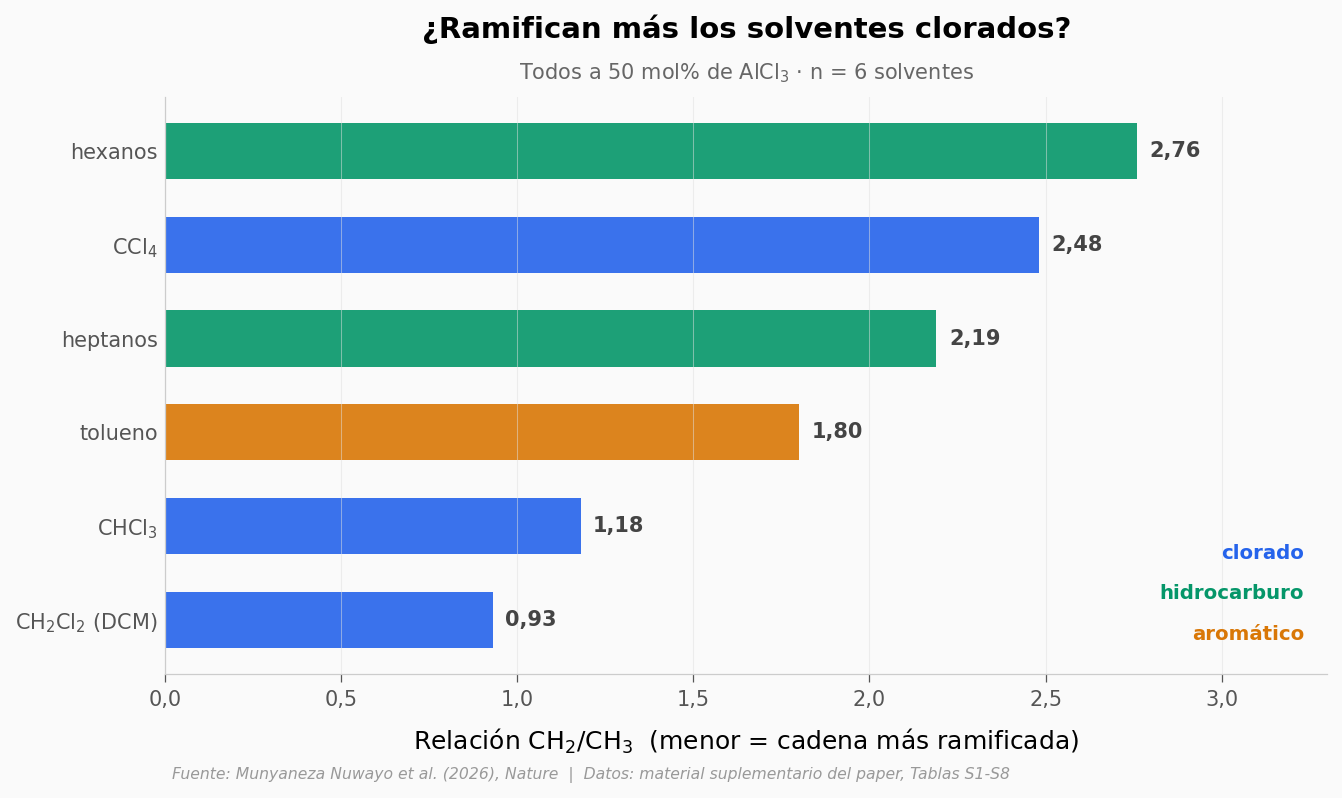

Rango completo: 0.93 (diclorometano) - 2.76 (hexanos) = factor 2.97
Clorados: 0.93 - 2.48  -> el CCl4 (2,48) cae dentro del rango de los hidrocarburos.
   La regla "clorado = mas ramificado" NO se sostiene con n = 6.

Ramificacion vs viscosidad (n = 6): rho = +0.89, p = 0.019
Ojo con el n: seis aceites que ademas difieren en olefina Y solvente.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿el solvente cambia la forma de la cadena tanto como el catalizador?

s = solventes.sort_values('ich2_ich3').copy()
color_tipo = {'clorado': COLOR_DATOS, 'hidrocarburo': COLOR_SECUNDARIO,
              'aromatico': COLOR_REFERENCIA}
# Fórmulas con subíndices y tipos con tilde (solo para mostrar)
s['nombre'] = s.solvente.replace({'CH2Cl2 (DCM)': 'CH$_2$Cl$_2$ (DCM)',
                                  'CHCl3': 'CHCl$_3$', 'CCl4': 'CCl$_4$'})
etiqueta_tipo = {'clorado': 'clorado', 'hidrocarburo': 'hidrocarburo',
                 'aromatico': 'aromático'}

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(s.nombre, s.ich2_ich3, color=[color_tipo[t] for t in s.tipo_solvente],
        alpha=0.9, height=0.6)
for solv, v in zip(s.nombre, s.ich2_ich3):
    ax.annotate(f'{v:.2f}'.replace('.', ','), xy=(v, solv), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=10,
                fontweight='bold', color='#444444')
ax.set_xlabel('Relación CH$_2$/CH$_3$  (menor = cadena más ramificada)')
ax.set_xlim(0, 3.3)
# Coma decimal en los ticks, para no mezclar convenciones dentro de la gráfica
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v:.1f}'.replace('.', ',')))
ax.set_title('¿Ramifican más los solventes clorados?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Todos a 50 mol% de AlCl$_3$ · n = 6 solventes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
for tipo, y in [('clorado', 0.20), ('hidrocarburo', 0.13), ('aromatico', 0.06)]:
    ax.text(0.98, y, etiqueta_tipo[tipo], transform=ax.transAxes, fontsize=9.5,
            color=color_tipo[tipo], fontweight='bold', ha='right')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/solventes_ramificacion.png', dpi=200, bbox_inches='tight')
plt.show()

clorados = s[s.tipo_solvente == 'clorado'].ich2_ich3
print(f'Rango completo: {s.ich2_ich3.min():.2f} (diclorometano) - '
      f'{s.ich2_ich3.max():.2f} (hexanos) = factor '
      f'{s.ich2_ich3.max()/s.ich2_ich3.min():.2f}')
print(f'Clorados: {clorados.min():.2f} - {clorados.max():.2f}  '
      f'-> el CCl4 (2,48) cae dentro del rango de los hidrocarburos.')
print('   La regla "clorado = mas ramificado" NO se sostiene con n = 6.\n')

rho, p = stats.spearmanr(olefina.branching_ratio_pct,
                         olefina.viscosidad_dinamica_pas)
print(f'Ramificacion vs viscosidad (n = {len(olefina)}): '
      f'rho = {rho:+.2f}, p = {p:.3f}')
print('Ojo con el n: seis aceites que ademas difieren en olefina Y solvente.')

---

## Fuentes

<!-- PLACEHOLDER_SOURCES_FOOTER -->

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — reproducible de punta a punta.*